# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [10]:
!pip install -q torch transformers pillow matplotlib scikit-learn requests


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Carga del modelo CLIP

En esta sección se carga el modelo **openai/clip-vit-base-patch32** junto con su procesador. Este modelo permite convertir imágenes y textos en vectores (embeddings) que pueden compararse directamente dentro del mismo espacio vectorial.

In [11]:
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# SETUP: Cargar el modelo CLIP y los datos
# ==========================================
print("Cargando modelo CLIP...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

Cargando modelo CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

## Obtención de embeddings

Se descargan algunas imágenes de ejemplo y se crean sus respectivas descripciones en texto.

Posteriormente, CLIP genera un embedding para cada imagen y cada texto, los cuales serán utilizados en los siguientes análisis.

In [12]:
# Imágenes de prueba (obtenidas de internet para el ejemplo)
urls = [
    "https://images.unsplash.com/photo-1517849845537-4d257902454a?q=80&w=735&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D", # Perro
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=1143&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D", # Gato
    "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"  # Coche
]
images = [Image.open(requests.get(url, stream=True).raw) for url in urls]

# Textos descriptivos correspondientes
texts = ["foto de un perro", "foto de un gato", "foto de un coche deportivo"]

# ==========================================
# PASO 1: Obtener embeddings de imágenes y textos
# ==========================================
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = model(**inputs)
    # Extraer embeddings
    image_embeds = outputs.image_embeds
    text_embeds = outputs.text_embeds
    
    # Normalizar los vectores (L2 normalization) crucial para comparar con similitud coseno
    image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

# ==========================================
# PASO 2: Mostrar que ambos viven en el mismo espacio
# ==========================================
print("\n--- PASO 2: Dimensión de los Embeddings ---")
print(f"Shape embeddings de imágenes: {image_embeds.shape}")
print(f"Shape embeddings de texto: {text_embeds.shape}")
print("Al tener la misma dimensión (ej. 512), comprobamos que comparten el mismo espacio latente.")



--- PASO 2: Dimensión de los Embeddings ---
Shape embeddings de imágenes: torch.Size([3, 512])
Shape embeddings de texto: torch.Size([3, 512])
Al tener la misma dimensión (ej. 512), comprobamos que comparten el mismo espacio latente.


## Visualización mediante PCA

Los embeddings generados por CLIP poseen cientos de dimensiones, por lo que resulta difícil visualizarlos directamente.

Para observar su distribución se utiliza **PCA (Principal Component Analysis)**, reduciendo los vectores a dos dimensiones.

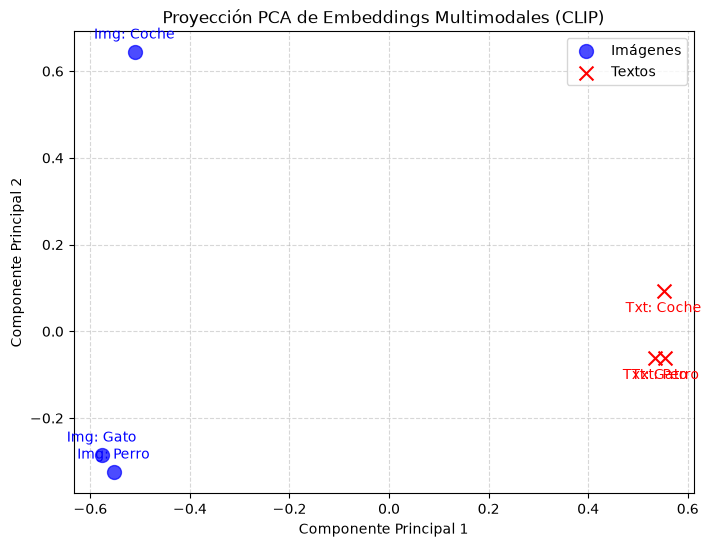


--- PASO 4: Similitud Coseno (Búsqueda) ---

Buscando imagen para el texto: 'foto de un perro'
  -> Similitud con imagen de [Perro]: 0.2814
  -> Similitud con imagen de [Gato]: 0.2177
  -> Similitud con imagen de [Coche]: 0.1623
  ✅ El modelo dice que 'foto de un perro' se empareja mejor con la Imagen de [Perro]

Buscando imagen para el texto: 'foto de un gato'
  -> Similitud con imagen de [Perro]: 0.2368
  -> Similitud con imagen de [Gato]: 0.2802
  -> Similitud con imagen de [Coche]: 0.1724
  ✅ El modelo dice que 'foto de un gato' se empareja mejor con la Imagen de [Gato]

Buscando imagen para el texto: 'foto de un coche deportivo'
  -> Similitud con imagen de [Perro]: 0.2047
  -> Similitud con imagen de [Gato]: 0.1818
  -> Similitud con imagen de [Coche]: 0.2184
  ✅ El modelo dice que 'foto de un coche deportivo' se empareja mejor con la Imagen de [Coche]


In [13]:

# ==========================================
# PASO 3: Proyectar vectores a 2D (PCA) y graficarlos
# ==========================================
# Convertir a numpy y concatenar para hacer el PCA sobre todo el conjunto a la vez
img_emb_np = image_embeds.numpy()
txt_emb_np = text_embeds.numpy()
all_embeds = np.concatenate((img_emb_np, txt_emb_np), axis=0)

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(all_embeds)

# Separar nuevamente en imágenes y textos
img_2d = embeds_2d[:len(images)]
txt_2d = embeds_2d[len(images):]

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(img_2d[:, 0], img_2d[:, 1], c='blue', label='Imágenes', marker='o', s=100, alpha=0.7)
plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c='red', label='Textos', marker='x', s=100)

# Añadir etiquetas de texto a los puntos en el gráfico
labels = ["Perro", "Gato", "Coche"]
for i, label in enumerate(labels):
    plt.annotate(f"Img: {label}", (img_2d[i, 0], img_2d[i, 1]), xytext=(0, 10), textcoords='offset points', ha='center', color='blue')
    plt.annotate(f"Txt: {label}", (txt_2d[i, 0], txt_2d[i, 1]), xytext=(0, -15), textcoords='offset points', ha='center', color='red')

plt.title("Proyección PCA de Embeddings Multimodales (CLIP)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ==========================================
# PASO 4: Verificar emparejamientos usando cosine similarity
# ==========================================
print("\n--- PASO 4: Similitud Coseno (Búsqueda) ---")
# Matriz de similitud: Textos (filas) vs Imágenes (columnas)
similarity_matrix = cosine_similarity(txt_emb_np, img_emb_np)

for i, text in enumerate(texts):
    print(f"\nBuscando imagen para el texto: '{text}'")
    for j, label in enumerate(labels):
        print(f"  -> Similitud con imagen de [{label}]: {similarity_matrix[i, j]:.4f}")
    
    # Búsqueda Texto -> Imagen (argmax por fila)
    best_img_idx = np.argmax(similarity_matrix[i])
    print(f"  ✅ El modelo dice que '{text}' se empareja mejor con la Imagen de [{labels[best_img_idx]}]")

### Observaciones

Al observar la proyección PCA, se evidencia una clara separación en el eje del Componente Principal 1 entre las modalidades (imágenes a la izquierda, textos a la derecha). Esto no es un error, sino un fenómeno estructural documentado en arquitecturas de aprendizaje contrastivo llamado **Modality Gap** (Brecha de Modalidad).

Aunque CLIP entrena ambos encoders (ViT y Transformer) para mapear al mismo espacio latente de 512 dimensiones, la inicialización y la arquitectura inherentemente distinta de los modelos hace que formen clusters en subregiones separadas. La similitud coseno funciona perfectamente porque evalúa el **ángulo** entre vectores, pero la proyección PCA lineal prioriza la mayor varianza, que en este caso, es el origen del dato.

## Prueba: Similitud del coseno

Una vez obtenidos los embeddings, se calcula la **similitud del coseno** entre cada imagen y cada descripción.

Valores cercanos a **1** indican una mayor relación semántica entre la imagen y el texto, mientras que valores menores indican que ambos representan conceptos diferentes.

In [21]:
import pandas as pd

# Normalizar los embeddings (por seguridad)
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

# Calcular la matriz de similitud
similarity = image_embeds @ text_embeds.T

# Mostrar resultados en una tabla
similarity_df = pd.DataFrame(
    similarity.detach().cpu().numpy(),
    index=[f"Imagen {i+1}" for i in range(len(images))],
    columns=texts
)

print("Matriz de similitud del coseno:")
display(similarity_df.round(3))

Matriz de similitud del coseno:


,foto de un perro,foto de un gato,foto de un coche deportivo
Imagen 1,0.281,0.237,0.205
Imagen 2,0.218,0.280,0.182
Imagen 3,0.162,0.172,0.218


### Análisis

Se observa que cada imagen obtiene la mayor similitud con la descripción que realmente le corresponde.

Esto confirma que CLIP logra representar imágenes y textos relacionados en posiciones cercanas dentro del mismo espacio vectorial, facilitando tareas de búsqueda y comparación multimodal.

# Prueba: Comparación entre PCA y t-SNE

Aunque PCA es una técnica ampliamente utilizada para reducir dimensionalidad, existen otros métodos como **t-SNE**, que priorizan la preservación de la estructura local de los datos.

Se realizará una comparación visual entre ambos métodos.

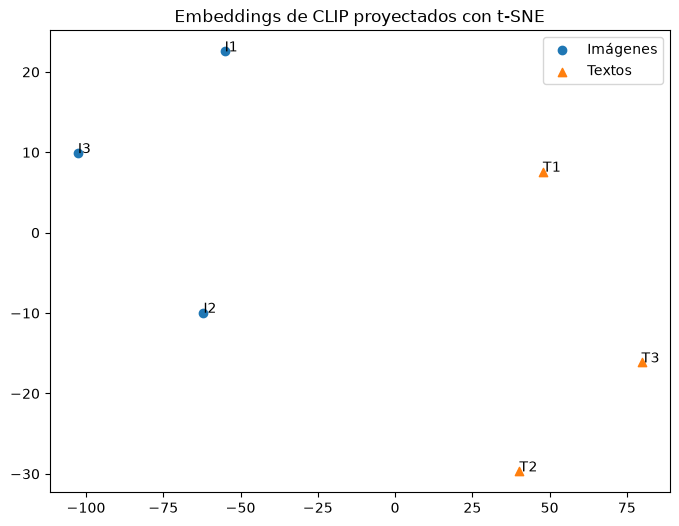

In [24]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Unir embeddings
all_embeddings = np.vstack([
    image_embeds.detach().cpu().numpy(),
    text_embeds.detach().cpu().numpy()
])

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=3
)

reduced = tsne.fit_transform(all_embeddings)

img_points = reduced[:len(images)]
txt_points = reduced[len(images):]

plt.figure(figsize=(8,6))

plt.scatter(img_points[:,0], img_points[:,1], marker='o', label='Imágenes')
plt.scatter(txt_points[:,0], txt_points[:,1], marker='^', label='Textos')

for i in range(len(images)):
    plt.text(img_points[i,0], img_points[i,1], f"I{i+1}")
    plt.text(txt_points[i,0], txt_points[i,1], f"T{i+1}")

plt.title("Embeddings de CLIP proyectados con t-SNE")
plt.legend()
plt.show()

### Comparación

En este caso ambos métodos permiten distinguir agrupaciones entre imágenes y textos.

PCA ofrece una representación global más estable, mientras que t-SNE puede mostrar agrupaciones locales con mayor claridad, aunque depende más de sus parámetros.

# Observación: Modality Gap

Durante la visualización puede apreciarse que, aunque imágenes y textos relacionados se encuentran cercanos, todavía existe cierta separación entre ambas modalidades.

Este comportamiento es conocido como **Modality Gap** y es una característica habitual en modelos multimodales como CLIP. A pesar de ello, el modelo logra mantener suficiente cercanía para realizar comparaciones exitosas entre imágenes y texto.

# Conclusiones

En esta práctica se comprobó que CLIP representa imágenes y texto dentro de un mismo espacio vectorial.

La reducción de dimensionalidad mediante PCA permitió visualizar la distribución de los embeddings, mientras que la similitud del coseno confirmó que las imágenes presentan mayor relación con sus descripciones correspondientes.

Como análisis adicional se comparó PCA con t-SNE y se discutió el fenómeno conocido como *Modality Gap*, observándose que, aunque existe cierta separación entre modalidades, el modelo mantiene correctamente las asociaciones entre imágenes y texto.

Estos resultados muestran cómo los modelos multimodales pueden comprender y relacionar información proveniente de diferentes tipos de datos.